<a href="https://colab.research.google.com/github/Pranayshukla0610/Linear_Regression/blob/main/Advanced_Socioeconomic_Income_Prediction_using_Linear_Regression_with_End_to_End_ML_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv('/content/data (4).csv')
df.head()

,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
0,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,72510
1,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,75462
2,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,71748
3,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,74520
4,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,640210


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             10000 non-null  int64 
 1   Education_Level                 10000 non-null  object
 2   Occupation                      10000 non-null  object
 3   Number_of_Dependents            10000 non-null  int64 
 4   Location                        10000 non-null  object
 5   Work_Experience                 10000 non-null  int64 
 6   Marital_Status                  10000 non-null  object
 7   Employment_Status               10000 non-null  object
 8   Household_Size                  10000 non-null  int64 
 9   Homeownership_Status            10000 non-null  object
 10  Type_of_Housing                 10000 non-null  object
 11  Gender                          10000 non-null  object
 12  Primary_Mode_of_Transportation  10000 non-null 

In [20]:
df.describe(include='all')

,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
count,10000.000000,10000,10000,10000.000000,10000,10000.000000,10000,10000,10000.000000,10000,10000,10000,10000,1.000000e+04
unique,NaN,4,5,NaN,3,NaN,3,3,NaN,2,3,2,4,NaN
top,NaN,Bachelor's,Healthcare,NaN,Urban,NaN,Married,Full-time,NaN,Own,Single-family home,Male,Public transit,NaN
freq,NaN,4058,3035,NaN,7037,NaN,5136,5004,NaN,6018,4055,5123,4047,NaN
mean,44.021700,NaN,NaN,2.527000,NaN,24.858800,NaN,NaN,3.989600,NaN,NaN,NaN,NaN,8.168382e+05
std,15.203998,NaN,NaN,1.713991,NaN,14.652622,NaN,NaN,2.010496,NaN,NaN,NaN,NaN,1.821089e+06
min,18.000000,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,3.104400e+04
25%,31.000000,NaN,NaN,1.000000,NaN,12.000000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,6.844600e+04
50%,44.000000,NaN,NaN,3.000000,NaN,25.000000,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,7.294300e+04
75%,57.000000,NaN,NaN,4.000000,NaN,37.000000,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,3.506675e+05


In [21]:
df.isnull().sum()

,0
Age,0
Education_Level,0
Occupation,0
Number_of_Dependents,0
Location,0
Work_Experience,0
Marital_Status,0
Employment_Status,0
Household_Size,0
Homeownership_Status,0


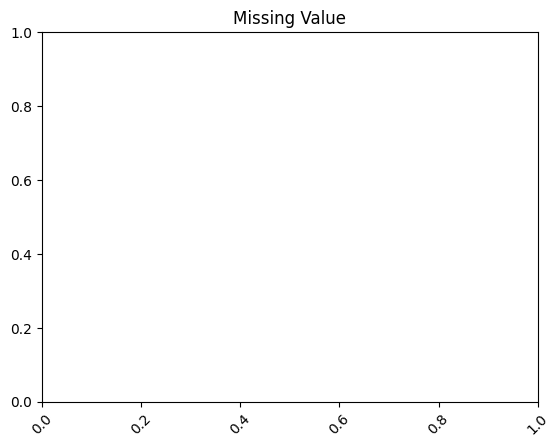

In [22]:
missing = df.isnull().sum()
missing = missing[missing > 0]

sns.barplot(x=missing.index, y=missing.values)
plt.xticks(rotation=45)
plt.title('Missing Value')
plt.show()

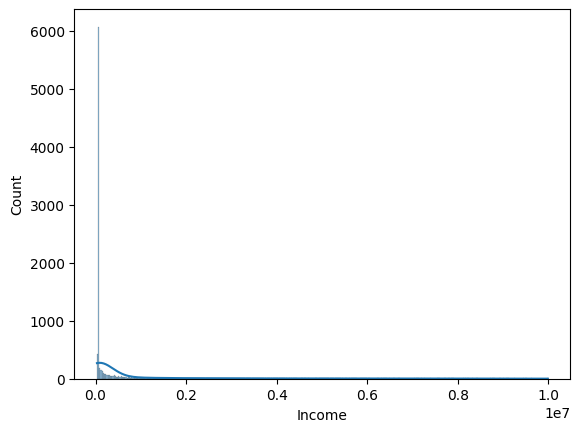

In [23]:
sns.histplot(df['Income'],kde=True)
plt.show()

In [24]:
df['Income'] = np.log1p(df['Income'])
df.head()

,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
0,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,11.191494
1,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,11.231398
2,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,11.180929
3,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,11.218836
4,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,13.369553


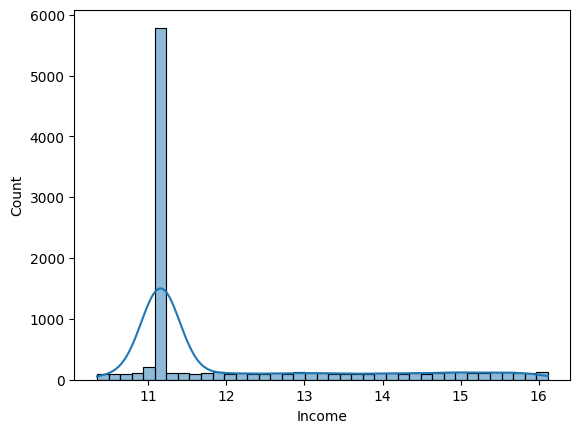

In [25]:
sns.histplot(df['Income'],kde=True)
plt.show()

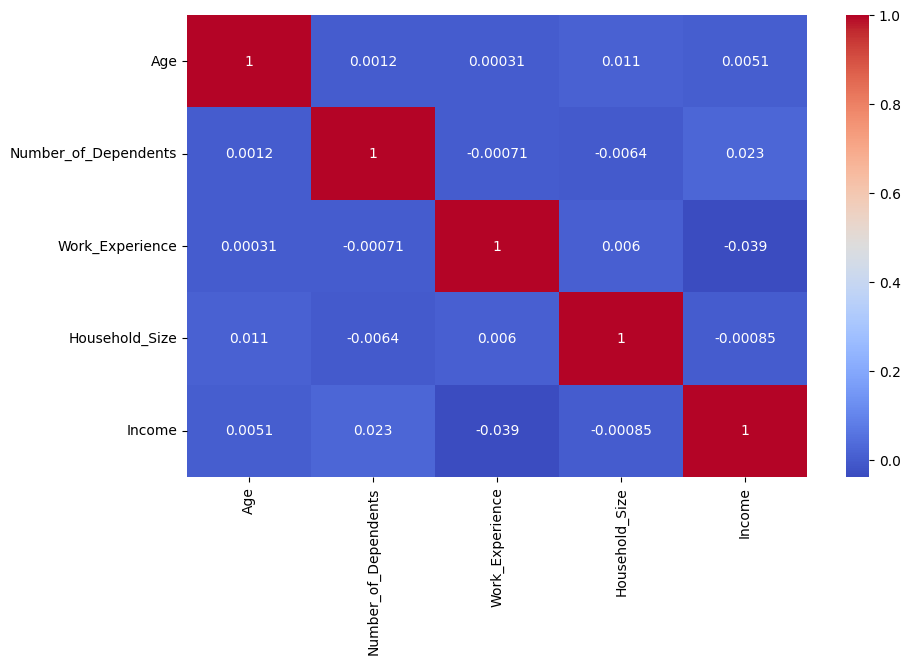

In [26]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.select_dtypes(include=['int64','float64'])

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

                feature        VIF
0                   Age   8.461569
1  Number_of_Dependents   3.109508
2       Work_Experience   3.695153
3        Household_Size   4.706767
4                Income  14.315455


In [28]:
df['Age_Education'] = df['Age'] * df['Education_Level']
df.head()

,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income,Age_Education
0,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,11.191494,Master'sMaster'sMaster'sMaster'sMaster'sMaster...
1,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,11.231398,High SchoolHigh SchoolHigh SchoolHigh SchoolHi...
2,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,11.180929,Bachelor'sBachelor'sBachelor'sBachelor'sBachel...
3,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,11.218836,High SchoolHigh SchoolHigh SchoolHigh SchoolHi...
4,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,13.369553,Bachelor'sBachelor'sBachelor'sBachelor'sBachel...


In [29]:
df = pd.get_dummies(df, drop_first=True)

In [30]:
df.head()

,Age,Number_of_Dependents,Work_Experience,Household_Size,Income,Education_Level_Doctorate,Education_Level_High School,Education_Level_Master's,Occupation_Finance,Occupation_Healthcare,...,Age_Education_Master'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster's,Age_Education_Master'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster's,Age_Education_Master'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster's,Age_Education_Master'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster's,Age_Education_Master'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster's,Age_Education_Master'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster's,Age_Education_Master'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster's,Age_Education_Master'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaster'sMaste

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaler = scaler.fit_transform(df.drop('Income',axis=1))

In [32]:
from sklearn.model_selection import train_test_split
X = df.drop('Income',axis=1)
y = df['Income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [35]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

Ridge()

In [36]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.2)
lasso.fit(X_train, y_train)

Lasso(alpha=0.2)

In [37]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 1.5281663922487325
R2: 0.0013824909013340214


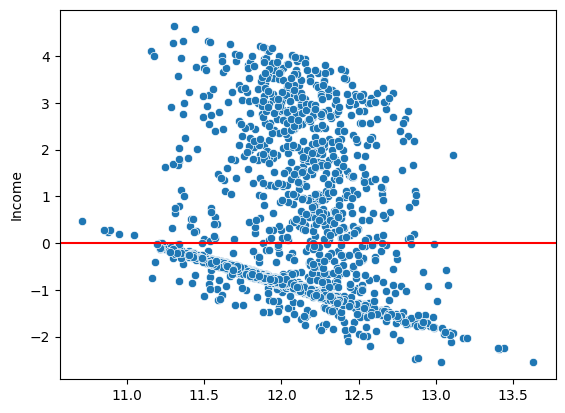

In [38]:
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')

<Axes: xlabel='Income', ylabel='Count'>

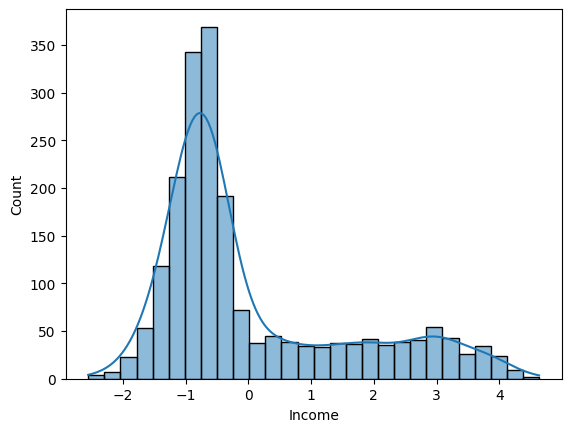

In [39]:
sns.histplot(residuals, kde=True)

In [40]:
from sklearn.model_selection import GridSearchCV

params = {'alpha': [0.01, 0.1, 1, 10]}

grid = GridSearchCV(Ridge(), params, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'alpha': 10}


In [41]:
#FINAL OUTPUT
##The model has almost zero explanatory power.
##The model explains only 0.14% of the variance in income
##~99.86% of variation is NOT captured
##The Linear Regression model failed to learn any meaningful relationship between the input features and the target variable (Income).